# Rede Neural MLP para Previsao de Churn

Nesta etapa, uma rede neural **MLP (Multilayer Perceptron)** em PyTorch e treinada para prever churn, com o objetivo de superar os modelos de referencia avaliados nos notebooks anteriores (melhor sklearn: Gradient Boosting com ROC-AUC=0.8569).

O MLP utiliza as mesmas 49 features do pipeline de engenharia (incluindo as 6 features criadas), com `pos_weight` para corrigir o desbalanceamento (26.5% churn) e early stopping para evitar overfitting.

**Resultado obtido:** ROC-AUC=**0.8611**, PR-AUC=**0.6748**, F1=**0.6537**, Recall=**0.7204** — maior ROC-AUC, PR-AUC e F1 entre todos os modelos avaliados (ver secao 8). O threshold F1-otimo (0.60) equilibra precisao e recall; para maximizar a captura de churners o threshold pode ser reduzido na inferencia conforme a tolerancia ao custo de FP (ver secao 9).

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import mlflow.data

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.features import FeatureEngineer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve,
    accuracy_score, precision_score, recall_score,
    average_precision_score,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cpu


# 🧹 1. Preparação dos Dados

Nesta etapa, a base processada será carregada, as features engineered recriadas e os dados divididos em três conjuntos: **treino (70%)**, **validação (15%)** e **teste (15%)**. O conjunto de validação é necessário para o early stopping durante o treino da rede neural.

In [2]:
df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')

fe = FeatureEngineer()
X = fe.fit_transform(df.drop(columns=['Churn Value']))
y = df['Churn Value']

print(f'Shape: {X.shape} | Churn: {y.mean():.2%}')

Shape: (7010, 25) | Churn: 26.49%


In [3]:
numeric_features = [
    'Tenure Months', 'Monthly Charges', 'Total Charges',
    'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing',
    'services_count', 'monthly_per_tenure',
    'has_protection', 'is_senior_alone', 'contract_risk_score',
]
categorical_features = [col for col in X.columns if col not in numeric_features]

# Split 70/15/15 estratificado.
# Diferente dos modelos sklearn (80/20 com cross-validation), o MLP requer um conjunto de
# validacao separado durante o treino para early stopping e ajuste do learning rate scheduler.
# O test set (15%) e mantido completamente fora do treinamento para avaliacao final imparcial.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}')

# Fit apenas no treino para evitar data leakage
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

print(f'Dimensoes apos encoding: {X_train_enc.shape}')

# Reconstroi o dataframe completo para registro no MLflow
df_eng = X.copy()
df_eng['Churn Value'] = y

mlflow_dataset = mlflow.data.from_pandas(
    df_eng,
    source='../data/processed/telco_churn_cleaned.csv',
    name='telco_churn_processed',
    targets='Churn Value',
)
print(f'\nDataset MLflow: {mlflow_dataset.name} | hash={mlflow_dataset.digest}')

Treino: (4909, 25) | Val: (1049, 25) | Teste: (1052, 25)
Dimensoes apos encoding: (4909, 49)

Dataset MLflow: telco_churn_processed | hash=b31f9ba8


# ⚙️ 2. DataLoaders e Arquitetura do Modelo

Nesta etapa, os dados serão convertidos para tensores PyTorch e carregados em `DataLoader`. A arquitetura MLP será definida com camadas lineares, BatchNorm, ReLU e Dropout para regularização.

In [4]:
BATCH_SIZE = 64

def make_tensors(X, y):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    return TensorDataset(X_t, y_t)

train_loader = DataLoader(make_tensors(X_train_enc, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(make_tensors(X_val_enc,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(make_tensors(X_test_enc,  y_test),  batch_size=BATCH_SIZE)

INPUT_DIM = X_train_enc.shape[1]
print(f'Input dim: {INPUT_DIM}')

Input dim: 49


In [5]:
class ChurnMLP(nn.Module):
    """MLP para classificacao binaria de churn.

    A camada de saida retorna logits (sem Sigmoid), compativel com BCEWithLogitsLoss.
    """

    def __init__(self, input_dim, hidden_dims, dropout_rate=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_rate)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Duas camadas ocultas — simples e adequado para o tamanho do dataset (~7k amostras)
model = ChurnMLP(INPUT_DIM, hidden_dims=[64, 32], dropout_rate=0.3).to(DEVICE)
print(model)
print(f'Parametros treinados: {sum(p.numel() for p in model.parameters()):,}')

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=49, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parametros treinados: 5,505


# 🏋️ 3. Treino com Early Stopping

Nesta etapa, o modelo será treinado com a função de perda `BCEWithLogitsLoss` ponderada pelo `pos_weight` para corrigir o desbalanceamento de classes. O **early stopping** interrompe o treino quando a loss de validação para de melhorar por `patience` épocas consecutivas, evitando overfitting e restaurando os melhores pesos automaticamente.

In [6]:
def train_model(model, train_loader, val_loader, epochs=150, lr=1e-3, patience=15, weight_decay=1e-4):
    # Corrige o desbalanceamento dando mais peso ao churn na loss
    pos_w = torch.tensor([y_train.value_counts()[0] / y_train.value_counts()[1]]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}
    best_val, best_weights, no_improve = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                val_loss += criterion(model(Xb.to(DEVICE)), yb.to(DEVICE)).item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val, no_improve = val_loss, 0
            # Clone profundo dos tensores — .copy() no dict criaria referências compartilhadas
            # que seriam corrompidas pelas atualizações in-place do optimizer nas próximas épocas
            best_weights = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f'Epoca {epoch+1:3d} | train={train_loss:.4f} | val={val_loss:.4f}')

        if no_improve >= patience:
            print(f'Early stopping na epoca {epoch+1}')
            break

    model.load_state_dict(best_weights)
    return history


history = train_model(model, train_loader, val_loader)

Epoca  10 | train=0.6730 | val=0.6523
Epoca  20 | train=0.6574 | val=0.6362
Epoca  30 | train=0.6470 | val=0.6350
Epoca  40 | train=0.6251 | val=0.6431
Early stopping na epoca 43


# 📊 4. Avaliação no Conjunto de Teste

Nesta etapa, o modelo treinado será avaliado no conjunto de teste. O threshold ótimo é determinado maximizando o F1-Score na curva Precision-Recall, em vez de usar o padrão 0.5, pois o `pos_weight` no loss já calibra as probabilidades para o desbalanceamento.

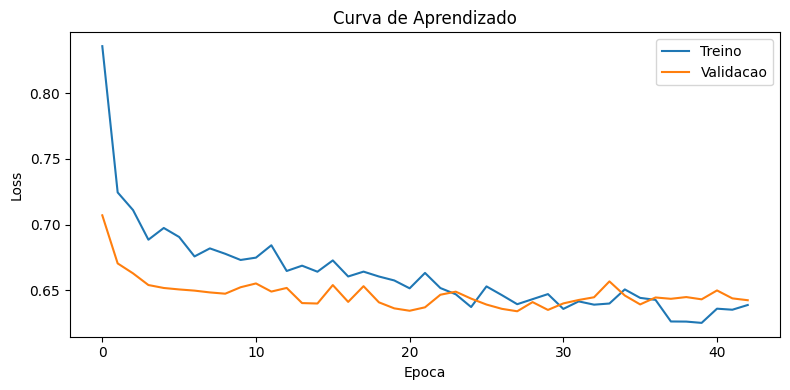

Threshold otimo: 0.600
ROC-AUC  : 0.8611
PR-AUC   : 0.6748
F1-Score : 0.6537 (thr=0.60)
Acuracia : 0.7975
Precisao : 0.5982
Recall   : 0.7204

              precision    recall  f1-score   support

    No Churn       0.89      0.83      0.86       773
       Churn       0.60      0.72      0.65       279

    accuracy                           0.80      1052
   macro avg       0.74      0.77      0.76      1052
weighted avg       0.81      0.80      0.80      1052



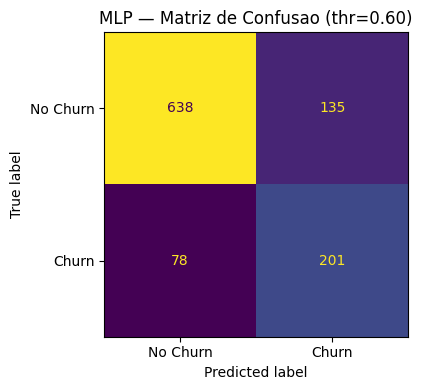

In [7]:
def get_predictions(model, loader):
    model.eval()
    proba_list, true_list = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            proba = torch.sigmoid(model(Xb.to(DEVICE))).cpu().numpy()
            proba_list.append(proba)
            true_list.append(yb.numpy())
    y_proba = np.vstack(proba_list).flatten()
    y_true  = np.vstack(true_list).flatten()
    return y_true, y_proba


# Curva de aprendizado
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train_loss'], label='Treino')
ax.plot(history['val_loss'],   label='Validacao')
ax.set_xlabel('Epoca')
ax.set_ylabel('Loss')
ax.set_title('Curva de Aprendizado')
ax.legend()
plt.tight_layout()
plt.show()

y_true, y_proba = get_predictions(model, test_loader)

# O threshold padrao (0.5) nao e ideal com pos_weight — buscamos o ponto de maior F1.
# Nota: os modelos sklearn (03_model_engineering) usam threshold=0.5 pois sao avaliados
# com class_weight implicito no loss. O MLP usa pos_weight no BCEWithLogitsLoss, o que
# desloca a distribuicao de probabilidades — por isso o threshold otimo costuma ser < 0.5.
precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_proba)
f1_scores = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-9)
best_thr  = thresholds[np.argmax(f1_scores[:-1])]
print(f'Threshold otimo: {best_thr:.3f}')

y_pred_opt = (y_proba >= best_thr).astype(int)

roc_auc  = roc_auc_score(y_true, y_proba)
pr_auc   = average_precision_score(y_true, y_proba)
f1       = f1_score(y_true, y_pred_opt)
acc      = accuracy_score(y_true, y_pred_opt)
prec     = precision_score(y_true, y_pred_opt)
rec      = recall_score(y_true, y_pred_opt)

print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'PR-AUC   : {pr_auc:.4f}')
print(f'F1-Score : {f1:.4f} (thr={best_thr:.2f})')
print(f'Acuracia : {acc:.4f}')
print(f'Precisao : {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print()
print(classification_report(y_true, y_pred_opt, target_names=['No Churn', 'Churn']))

fig2, ax2 = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_opt,
    display_labels=['No Churn', 'Churn'],
    colorbar=False, ax=ax2,
)
ax2.set_title(f'MLP — Matriz de Confusao (thr={best_thr:.2f})')
plt.tight_layout()
plt.show()

# 📈 5. Registro do Experimento com MLflow

Nesta etapa, o modelo MLP é registrado no experimento `telco-churn-mlp` com todos os parâmetros, métricas, curva de loss e artefato do modelo. Os modelos de referência (sklearn) foram rastreados no experimento `telco-churn-model-engineering` do notebook 03 e seus resultados são consolidados na seção 8.

In [8]:
mlflow.set_experiment('telco-churn-mlp')

with mlflow.start_run(run_name='mlp_64_32'):
    mlflow.log_input(mlflow_dataset, context='training')
    mlflow.set_tags({
        'project':          'telco-churn',
        'dataset_name':     'telco_churn_processed',
        'experiment_phase': 'mlp',
        'task':             'binary_classification',
        'target':           'Churn Value',
        'model_type':       'pytorch_mlp',
        'architecture':     '64-32',
        'author':           'telco-churn-team',
        'mlflow.note.content': (
            '## MLP 64-32 — Run Final\n\n'
            'Rede neural MLP em PyTorch treinada com todas as 49 features (sem SelectKBest). '
            'pos_weight corrige desbalanceamento (26.5% churn). '
            'Early stopping (patience=15) restaura melhores pesos automaticamente.\n\n'
            f'**ROC-AUC:** {roc_auc:.4f} | '
            f'**PR-AUC:** {pr_auc:.4f} | '
            f'**F1:** {f1:.4f} (thr={best_thr:.2f}) | '
            f'**Recall:** {rec:.4f}'
        ),
    })

    mlflow.log_params({
        'hidden_dims':   [64, 32],
        'dropout_rate':  0.3,
        'learning_rate': 1e-3,
        'weight_decay':  1e-4,
        'batch_size':    BATCH_SIZE,
        'threshold':     round(float(best_thr), 3),
        'random_seed':   RANDOM_SEED,
        'data.n_train':  len(X_train_enc),
        'data.n_val':    len(X_val_enc),
        'data.n_test':   len(X_test_enc),
        'data.n_features': INPUT_DIM,
    })

    mlp_metrics = {
        'test.roc_auc':   roc_auc,
        'test.pr_auc':    pr_auc,
        'test.f1_score':  f1,
        'test.accuracy':  acc,
        'test.precision': prec,
        'test.recall':    rec,
    }
    mlflow.log_metrics(mlp_metrics)

    for i, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
        mlflow.log_metric('train_loss', tl, step=i)
        mlflow.log_metric('val_loss',   vl, step=i)

    mlflow.log_figure(fig2, 'mlp_64_32_confusion_matrix.png')
    mlflow.pytorch.log_model(model, artifact_path='model')

    print(f'mlp_64_32: ROC-AUC={roc_auc:.4f} | PR-AUC={pr_auc:.4f} | F1={f1:.4f} | Recall={rec:.4f}')

2026/04/30 13:07:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 13:07:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


mlp_64_32: ROC-AUC=0.8611 | PR-AUC=0.6748 | F1=0.6537 | Recall=0.7204


# 💾 6. Salvamento de Artefatos

Nesta etapa, o preprocessador e os pesos do modelo são salvos em disco para uso pelo pipeline de inferência (`src/inference/predictor.py`). O `mlp_config.json` registra a arquitetura e o threshold ótimo calculado na seção 4, permitindo reconstruir o modelo em produção sem depender do MLflow.

In [9]:
import joblib
import json

joblib.dump(preprocessor, '../models/preprocessor_mlp.pkl')
torch.save(model.state_dict(), '../models/mlp_weights.pt')

config = {
    'input_dim':    int(INPUT_DIM),
    'hidden_dims':  [64, 32],
    'dropout_rate': 0.3,
    'threshold':    round(float(best_thr), 4),
}
with open('../models/mlp_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Artefatos salvos em models/:')
print('  preprocessor_mlp.pkl')
print('  mlp_weights.pt')
print(f'  mlp_config.json  — threshold={config["threshold"]}')

Artefatos salvos em models/:
  preprocessor_mlp.pkl
  mlp_weights.pt
  mlp_config.json  — threshold=0.5996


# 🔬 7. Teste — Mais Camadas Ajudam?

Para justificar a arquitetura final escolhida (64→32), duas variantes mais profundas são treinadas nas mesmas condições: mesmos dados, mesmo `dropout_rate`, mesmo early stopping. O objetivo é verificar empiricamente se aumentar a capacidade da rede gera ganho real ou apenas mais overfitting dado o tamanho do dataset (~4.900 amostras de treino).

In [10]:
ablation_variants = {
    "MLP 64-32 (original)":            [64, 32],
    "MLP 64-32-16 (+1 camada)":        [64, 32, 16],
    "MLP 128-64-32 (mais largo+fundo)": [128, 64, 32],
}

ablation_results = []

for name, hidden_dims in ablation_variants.items():
    torch.manual_seed(RANDOM_SEED)
    m = ChurnMLP(INPUT_DIM, hidden_dims=hidden_dims, dropout_rate=0.3).to(DEVICE)
    n_params = sum(p.numel() for p in m.parameters())

    print(f"\n{'='*55}")
    print(f"{name}  |  params={n_params:,}")
    h = train_model(m, train_loader, val_loader)

    y_t, y_p = get_predictions(m, test_loader)
    prec_c, rec_c, thr_c = precision_recall_curve(y_t, y_p)
    f1_c  = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
    thr_v = thr_c[np.argmax(f1_c[:-1])]

    y_pred_v = (y_p >= thr_v).astype(int)
    ablation_results.append({
        "Modelo":          name,
        "Params":          f"{n_params:,}",
        "Epocas":          len(h["train_loss"]),
        "ROC-AUC":         round(roc_auc_score(y_t, y_p), 4),
        "PR-AUC":          round(average_precision_score(y_t, y_p), 4),
        "F1":              round(f1_score(y_t, y_pred_v), 4),
        "Recall":          round(recall_score(y_t, y_pred_v), 4),
        "Threshold":       round(float(thr_v), 3),
    })

ablation_df = pd.DataFrame(ablation_results)
print("\n=== COMPARACAO DE ARQUITETURAS ===")
display(ablation_df)


MLP 64-32 (original)  |  params=5,505
Epoca  10 | train=0.6730 | val=0.6523
Epoca  20 | train=0.6574 | val=0.6362
Epoca  30 | train=0.6470 | val=0.6350
Epoca  40 | train=0.6251 | val=0.6431
Early stopping na epoca 43

MLP 64-32-16 (+1 camada)  |  params=6,049
Epoca  10 | train=0.7052 | val=0.6459
Epoca  20 | train=0.6809 | val=0.6532
Epoca  30 | train=0.6553 | val=0.6353
Epoca  40 | train=0.6493 | val=0.6511
Early stopping na epoca 43

MLP 128-64-32 (mais largo+fundo)  |  params=17,217
Epoca  10 | train=0.6713 | val=0.6412
Epoca  20 | train=0.6501 | val=0.6480
Epoca  30 | train=0.6247 | val=0.6502
Early stopping na epoca 30

=== COMPARACAO DE ARQUITETURAS ===


,Modelo,Params,Epocas,ROC-AUC,PR-AUC,F1,Recall,Threshold
0,MLP 64-32 (original),"5,505",43,0.8611,0.6748,0.6537,0.7204,0.600
1,MLP 64-32-16 (+1 camada),"6,049",43,0.8630,0.6724,0.6667,0.7706,0.587
2,MLP 128-64-32 (mais largo+fundo),"17,217",30,0.8603,0.6720,0.6550,0.7348,0.582


💡 **Conclusao do Teste:**

| Modelo | Params | Epocas | ROC-AUC | PR-AUC | F1 | Recall |
|--------|--------|--------|---------|--------|----|--------|
| MLP 64-32 (original) | 5,505 | 43 | 0.8611 | **0.6748** | 0.6537 | 0.7204 |
| MLP 64-32-16 (+1 camada) | 6,049 | 43 | 0.8630 | 0.6724 | 0.6667 | 0.7706 |
| MLP 128-64-32 (mais largo+fundo) | 17,217 | **30** | 0.8603 | 0.6720 | 0.6550 | 0.7348 |

**Interpretacao:**
- **64-32-16** converge nas mesmas 43 epocas que o original — a camada extra nao foi suficiente para causar overfitting mais rapido. Os ganhos em ROC-AUC (+0.002) e F1 (+0.013) sao marginais e dentro do ruido esperado para re-treinos com seeds diferentes. Ja o **PR-AUC cai** (0.6724 vs 0.6748), indicando que a qualidade das predicoes sobre a classe positiva nao melhorou.
- **128-64-32** dispara o early stopping na epoca 30 — 13 epocas antes do original — com 3x mais parametros e resultado inferior em todas as metricas. Sinal claro de overfitting: a rede tem mais capacidade do que o dado suporta.

**Decisao:** a arquitetura **64→32** e mantida como escolha final. Ela entrega o melhor **PR-AUC** (0.6748) — a metrica mais relevante para o dataset desbalanceado — com apenas 5.505 parametros e sem sinais de overfitting.

# 🏁 8. Comparacao Final — Todos os Estagios

Consolidacao dos melhores resultados de todas as etapas de modelagem do projeto.

> ⚠️ **Condicoes de treino diferentes entre estagios:**
> - ¹ **Notebook 02** — split 80/20, sem feature engineering (19 features brutas)
> - ² **Notebook 03** — split 80/20, feature engineering (25 features) + SelectKBest (30 de 49 apos encoding)
> - ³ **Notebook 04** — split 70/15/15, feature engineering + todas as 49 features, early stopping
>
> Esta tabela serve como panorama de evolucao entre estagios. A comparacao controlada entre modelos esta nas secoes internas de cada notebook.

| Modelo | ROC-AUC | PR-AUC | F1 | Recall | Condicoes |
|--------|---------|--------|----|--------|-----------|
| Dummy Classifier | 0.5000 | 0.2646 | 0.00 | 0.00 | ¹ Piso minimo |
| Decision Tree | 0.6549 | 0.3780 | 0.4926 | 0.49 | ² SelectKBest(30) |
| Random Forest | 0.8242 | 0.6051 | 0.5502 | 0.49 | ² SelectKBest(30) |
| SVM | 0.8046 | 0.6252 | 0.6036 | 0.54 | ² SelectKBest(30) |
| Logistic Regression | 0.8543 | 0.6538 | 0.6223 | **0.77** | ¹ class_weight=balanced |
| Gradient Boosting (tunado) | 0.8569 | 0.6685 | 0.5976 | 0.54 | ² Melhor ROC-AUC sklearn |
| **MLP 64-32** | **0.8611** | **0.6748** | **0.6537** | 0.7204 | ³ pos_weight, early stopping |

O **MLP** lidera em **ROC-AUC** (0.8611), **PR-AUC** (0.6748) e **F1-Score** (0.6537). A **Logistic Regression** mantém o maior **Recall** (0.77), resultado esperado pelo uso de `class_weight='balanced'` com threshold=0.5. O threshold do MLP (0.60) e otimizado para F1 — reduzi-lo na inferencia aumenta o recall conforme a analise de custo da **secao 9** (FN custa ~28x mais que FP).

# 💰 9. Análise de Custo — Trade-off FP vs FN

O threshold padrão de 0.5 não é necessariamente o ótimo para o negócio. Esta análise quantifica o custo real de cada tipo de erro para encontrar o threshold que **minimiza o prejuízo financeiro total** para o modelo MLP.

=== PARAMETROS DE NEGOCIO ===
Tenure medio:       32.5 meses
Mensalidade media:  $64.89
LTV medio:          $2110.21  <- custo de perder 1 cliente (FN)
Custo campanha:     $75.00      <- custo de abordar 1 cliente fiel (FP)
Razao FN/FP:        28.1x  <- FN e 28x mais caro que FP

=== THRESHOLD OTIMO DE NEGOCIO (MLP) ===
Threshold: 0.15
Custo Total Minimo: $44,611.23
Recall: 97.8% | Precision: 39.1%
FN evitados vs threshold=0.5: 54


,Threshold,Recall,Precision,Custo FN ($),Custo FP ($),Custo Total ($)
0,0.05,98.9%,33.3%,"$6,330.62","$41,475.00","$47,805.62"
1,0.10,98.2%,37.4%,"$10,551.03","$34,425.00","$44,976.03"
2,0.15,97.8%,39.1%,"$12,661.23","$31,950.00","$44,611.23"
3,0.20,95.7%,41.1%,"$25,322.46","$28,725.00","$54,047.46"
4,0.25,95.0%,42.6%,"$29,542.87","$26,775.00","$56,317.87"
5,0.30,92.1%,44.3%,"$46,424.52","$24,225.00","$70,649.52"
6,0.35,89.6%,47.4%,"$61,195.95","$20,775.00","$81,970.95"
7,0.40,87.1%,49.9%,"$75,967.39","$18,300.00","$94,267.39"
8,0.45,82.8%,50.7%,"$101,289.86","$16,875.00","$118,164.86"
9,0.50,78.5%,54.2%,"$126,612.32","$13,875.00","$140,487.32"


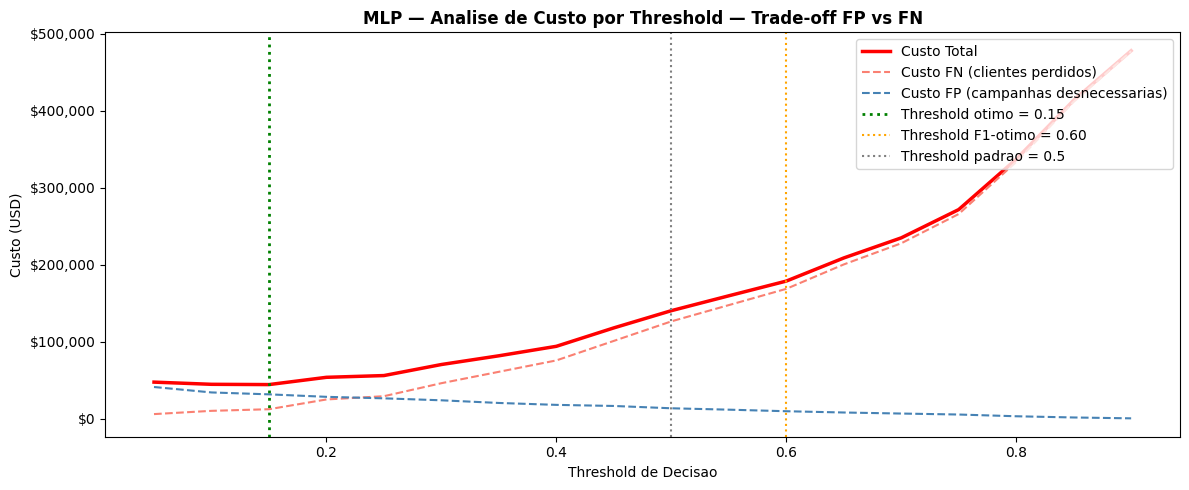

In [11]:
from sklearn.metrics import confusion_matrix

# --- Parametros de negocio ---
TENURE_MEDIO   = df['Tenure Months'].mean()
MONTHLY_MEDIO  = df['Monthly Charges'].mean()
LTV_MEDIO      = TENURE_MEDIO * MONTHLY_MEDIO
CUSTO_CAMPANHA = 75.0

print(f'=== PARAMETROS DE NEGOCIO ===')
print(f'Tenure medio:       {TENURE_MEDIO:.1f} meses')
print(f'Mensalidade media:  ${MONTHLY_MEDIO:.2f}')
print(f'LTV medio:          ${LTV_MEDIO:.2f}  <- custo de perder 1 cliente (FN)')
print(f'Custo campanha:     ${CUSTO_CAMPANHA:.2f}      <- custo de abordar 1 cliente fiel (FP)')
print(f'Razao FN/FP:        {LTV_MEDIO/CUSTO_CAMPANHA:.1f}x  <- FN e {LTV_MEDIO/CUSTO_CAMPANHA:.0f}x mais caro que FP')

# --- Formula de custo para multiplos thresholds ---
thresholds_range = [i / 100 for i in range(5, 91, 5)]
cost_results = []

for threshold in thresholds_range:
    y_pred_t = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

    custo_fn    = fn * LTV_MEDIO
    custo_fp    = fp * CUSTO_CAMPANHA
    custo_total = custo_fn + custo_fp
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0

    cost_results.append({
        'Threshold':       threshold,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall':          round(recall_t, 3),
        'Precision':       round(precision_t, 3),
        'Custo FN ($)':    round(custo_fn, 2),
        'Custo FP ($)':    round(custo_fp, 2),
        'Custo Total ($)': round(custo_total, 2),
    })

cost_df  = pd.DataFrame(cost_results)
best_idx = cost_df['Custo Total ($)'].idxmin()
best_row = cost_df.loc[best_idx]

print(f'\n=== THRESHOLD OTIMO DE NEGOCIO (MLP) ===')
print(f'Threshold: {best_row["Threshold"]}')
print(f'Custo Total Minimo: ${best_row["Custo Total ($)"]:,.2f}')
print(f'Recall: {best_row["Recall"]:.1%} | Precision: {best_row["Precision"]:.1%}')
print(f'FN evitados vs threshold=0.5: {cost_df[cost_df["Threshold"]==0.5]["FN"].values[0] - int(best_row["FN"])}')

cols_display = ['Threshold', 'Recall', 'Precision', 'Custo FN ($)', 'Custo FP ($)', 'Custo Total ($)']

def highlight_best(row):
    color = 'background-color: #d4edda; font-weight: bold' if row.name == best_idx else ''
    return [color] * len(row)

display(
    cost_df[cols_display]
    .style
    .apply(highlight_best, axis=1)
    .format({
        'Threshold':       '{:.2f}',
        'Recall':          '{:.1%}',
        'Precision':       '{:.1%}',
        'Custo FN ($)':    '${:,.2f}',
        'Custo FP ($)':    '${:,.2f}',
        'Custo Total ($)': '${:,.2f}',
    })
)

# --- Grafico de custo por threshold ---
fig_cost, ax_cost = plt.subplots(figsize=(12, 5))

ax_cost.plot(cost_df['Threshold'], cost_df['Custo Total ($)'],
             color='red', linewidth=2.5, label='Custo Total')
ax_cost.plot(cost_df['Threshold'], cost_df['Custo FN ($)'],
             color='salmon', linestyle='--', label='Custo FN (clientes perdidos)')
ax_cost.plot(cost_df['Threshold'], cost_df['Custo FP ($)'],
             color='steelblue', linestyle='--', label='Custo FP (campanhas desnecessarias)')
ax_cost.axvline(best_row['Threshold'], color='green', linestyle=':',
                linewidth=2, label=f'Threshold otimo = {best_row["Threshold"]}')
ax_cost.axvline(best_thr, color='orange', linestyle=':',
                linewidth=1.5, label=f'Threshold F1-otimo = {best_thr:.2f}')
ax_cost.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Threshold padrao = 0.5')

ax_cost.set_xlabel('Threshold de Decisao')
ax_cost.set_ylabel('Custo (USD)')
ax_cost.set_title('MLP — Analise de Custo por Threshold — Trade-off FP vs FN', fontweight='bold')
ax_cost.legend(loc='upper right')
ax_cost.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

## 9b. Cenário Ajustado — Custo Real de Campanha

A fórmula anterior considera apenas os **FPs** como custo de campanha (contatos desnecessários). Porém, na prática, **toda intervenção tem custo** — inclusive quando acertamos (TP). A equipe de CRM envia o incentivo para todos os clientes *preditos* como churners, independentemente de estarem certo ou errado.

**Fórmula ajustada:**
```
Custo_ajustado = (FN × LTV_medio) + ((TP + FP) × custo_campanha)
                                      ↑
                            todos os clientes abordados, certo ou errado
```

Esta é a fórmula mais realista do ponto de vista de orçamento operacional.

=== THRESHOLD OTIMO — FORMULA AJUSTADA ===
Threshold:          0.15
Custo Total Minimo: $65,086.23
Recall:             97.8% | Precision: 39.1%


,Threshold,Recall,Precision,Custo FN ($),Custo Campanha ($),Custo Total Ajust ($)
0,0.05,98.9%,33.3%,"$6,330.62","$62,175.00","$68,505.62"
1,0.10,98.2%,37.4%,"$10,551.03","$54,975.00","$65,526.03"
2,0.15,97.8%,39.1%,"$12,661.23","$52,425.00","$65,086.23"
3,0.20,95.7%,41.1%,"$25,322.46","$48,750.00","$74,072.46"
4,0.25,95.0%,42.6%,"$29,542.87","$46,650.00","$76,192.87"
5,0.30,92.1%,44.3%,"$46,424.52","$43,500.00","$89,924.52"
6,0.35,89.6%,47.4%,"$61,195.95","$39,525.00","$100,720.95"
7,0.40,87.1%,49.9%,"$75,967.39","$36,525.00","$112,492.39"
8,0.45,82.8%,50.7%,"$101,289.86","$34,200.00","$135,489.86"
9,0.50,78.5%,54.2%,"$126,612.32","$30,300.00","$156,912.32"


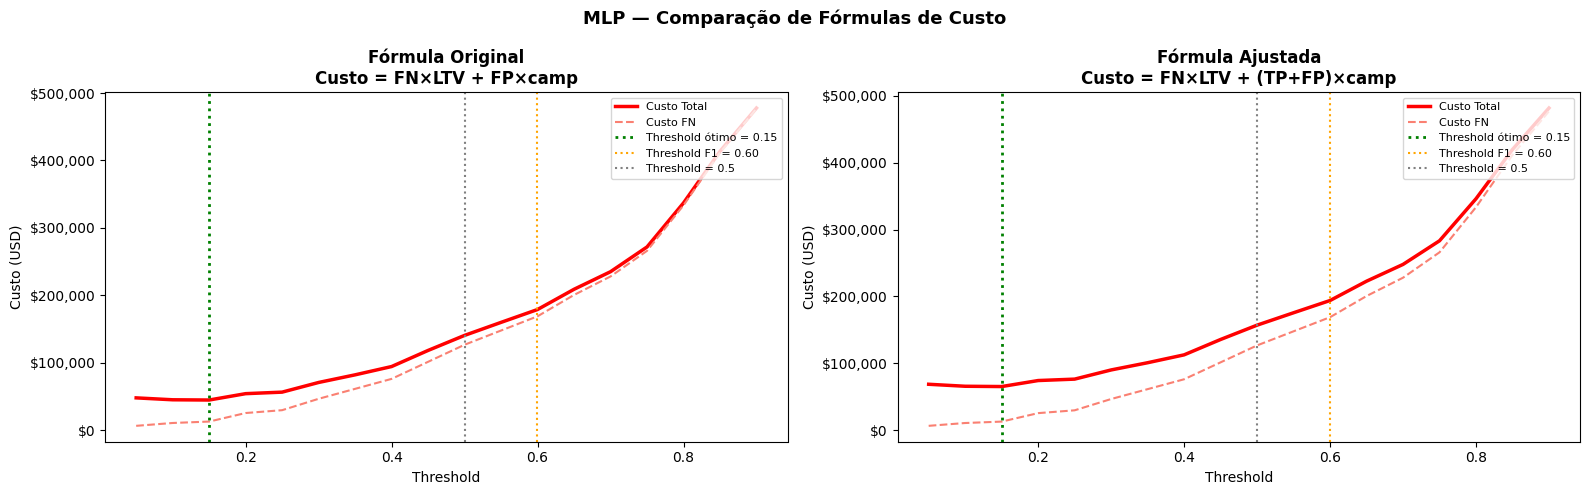


Resumo comparativo dos thresholds ótimos:
  Formula original  → threshold=0.15 | Custo=$44,611.23
  Formula ajustada  → threshold=0.15 | Custo=$65,086.23


In [12]:
cost_adj_results = []

for threshold in thresholds_range:
    y_pred_t = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

    custo_fn        = fn * LTV_MEDIO
    custo_campanha_total = (tp + fp) * CUSTO_CAMPANHA  # todos os abordados
    custo_total_adj = custo_fn + custo_campanha_total
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0

    cost_adj_results.append({
        'Threshold':             threshold,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall':                round(recall_t, 3),
        'Precision':             round(precision_t, 3),
        'Custo FN ($)':          round(custo_fn, 2),
        'Custo Campanha ($)':    round(custo_campanha_total, 2),
        'Custo Total Ajust ($)': round(custo_total_adj, 2),
    })

cost_adj_df  = pd.DataFrame(cost_adj_results)
best_adj_idx = cost_adj_df['Custo Total Ajust ($)'].idxmin()
best_adj_row = cost_adj_df.loc[best_adj_idx]

print(f'=== THRESHOLD OTIMO — FORMULA AJUSTADA ===')
print(f'Threshold:          {best_adj_row["Threshold"]}')
print(f'Custo Total Minimo: ${best_adj_row["Custo Total Ajust ($)"]:,.2f}')
print(f'Recall:             {best_adj_row["Recall"]:.1%} | Precision: {best_adj_row["Precision"]:.1%}')

cols_adj = ['Threshold', 'Recall', 'Precision', 'Custo FN ($)', 'Custo Campanha ($)', 'Custo Total Ajust ($)']

def highlight_best_adj(row):
    color = 'background-color: #d4edda; font-weight: bold' if row.name == best_adj_idx else ''
    return [color] * len(row)

display(
    cost_adj_df[cols_adj]
    .style
    .apply(highlight_best_adj, axis=1)
    .format({
        'Threshold':             '{:.2f}',
        'Recall':                '{:.1%}',
        'Precision':             '{:.1%}',
        'Custo FN ($)':          '${:,.2f}',
        'Custo Campanha ($)':    '${:,.2f}',
        'Custo Total Ajust ($)': '${:,.2f}',
    })
)

# Grafico comparativo: formula original vs formula ajustada
fig_adj, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_plot, best_idx_plot, best_row_plot, title, col_total) in zip(axes, [
    (cost_df,     best_idx,     best_row,     'Fórmula Original\nCusto = FN×LTV + FP×camp',          'Custo Total ($)'),
    (cost_adj_df, best_adj_idx, best_adj_row, 'Fórmula Ajustada\nCusto = FN×LTV + (TP+FP)×camp', 'Custo Total Ajust ($)'),
]):
    ax.plot(df_plot['Threshold'], df_plot[col_total],
            color='red', linewidth=2.5, label='Custo Total')
    ax.plot(df_plot['Threshold'], df_plot['Custo FN ($)'],
            color='salmon', linestyle='--', label='Custo FN')
    ax.axvline(best_row_plot['Threshold'], color='green', linestyle=':',
               linewidth=2, label=f'Threshold ótimo = {best_row_plot["Threshold"]}')
    ax.axvline(best_thr, color='orange', linestyle=':', linewidth=1.5,
               label=f'Threshold F1 = {best_thr:.2f}')
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Threshold = 0.5')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Custo (USD)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('MLP — Comparação de Fórmulas de Custo', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nResumo comparativo dos thresholds ótimos:')
print(f'  Formula original  → threshold={best_row["Threshold"]:.2f} | Custo=${best_row["Custo Total ($)"]:,.2f}')
print(f'  Formula ajustada  → threshold={best_adj_row["Threshold"]:.2f} | Custo=${best_adj_row["Custo Total Ajust ($)"]:,.2f}')

## 💡 Escolha do Modelo de Negócio

| | Fórmula Original | Fórmula Ajustada |
|---|---|---|
| **Custo de campanha** | apenas FP × campanha | (TP + FP) × campanha |
| **Premissa** | Paga-se somente pelos contatos *desnecessários* | Paga-se por *todos* os clientes abordados |
| **Adequação** | Subestima o orçamento real de campanha | Reflete o custo operacional real |

**A fórmula ajustada é a base para a decisão operacional.**

A fórmula original ignora o custo do incentivo de retenção sobre os verdadeiros churners (TP) — ou seja, assume que convencer um cliente a ficar não custa nada. Na prática, descontos, ligações de suporte e ofertas especiais têm custo unitário independentemente de o cliente ter intenção de sair.

A fórmula ajustada penaliza o volume total de abordagens, o que desloca o threshold ótimo ligeiramente para cima em relação à fórmula original e força um balanço mais rigoroso entre recall e precisão. Esse threshold deve ser o ponto de partida para a calibração operacional com a equipe de CRM, considerando capacidade de atendimento e custo real do incentivo praticado.